In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Section 1: Supervised Evaluation and Instance Difficulty

This notebook opens the workshop with a simple message: two models can obtain similar headline metrics while behaving very differently on easy and hard instances.


## Learning Goals

By the end of this section, participants should be able to:

- explain why accuracy alone is not enough;
- compare easy and hard toy datasets;
- inspect which examples are consistently hard;
- motivate the move from aggregate metrics to latent ability.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from utils.handson import (
    evaluate_models_on_dataset,
    make_toy_classification_dataset,
    plot_classification_dataset,
    plot_example_difficulty,
    summarize_classification_results,
    summarize_instance_difficulty,
)


## Step 1: Build an easy dataset

We start with a balanced and well-separated problem. This gives the room an intuitive baseline for what an *easy* classification task looks like.


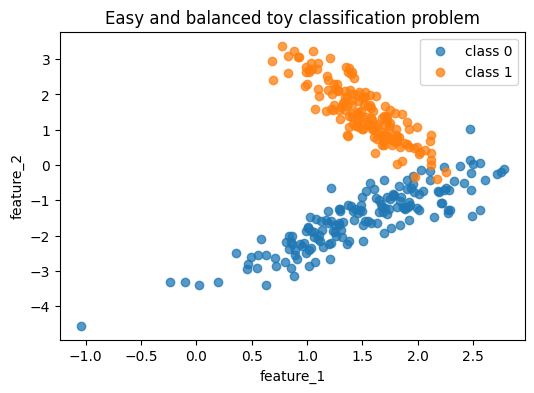

In [3]:
easy_df = make_toy_classification_dataset(
    n_samples=320,
    class_sep=1.5,
    flip_y=0.01,
    weights=(0.5, 0.5),
    random_state=42,
)

ax = plot_classification_dataset(easy_df)
ax.set_title('Easy and balanced toy classification problem')
plt.show()


In [4]:
easy_results = evaluate_models_on_dataset(easy_df, scenario='easy_balanced', random_state=42)
easy_summary = summarize_classification_results(easy_results)
easy_summary.round(3)


,scenario,model,accuracy,balanced_accuracy,f1,mean_difficulty_proxy
0,easy_balanced,decision_tree,0.990,0.990,0.989,0.010
1,easy_balanced,knn,0.969,0.969,0.969,0.054
2,easy_balanced,logistic_regression,0.979,0.979,0.979,0.116


## Step 2: Make the evaluation problem harder

We now reduce class separation, add noise, and introduce imbalance. The point is not to change the concept of evaluation, but to show that the same metrics become harder to interpret.


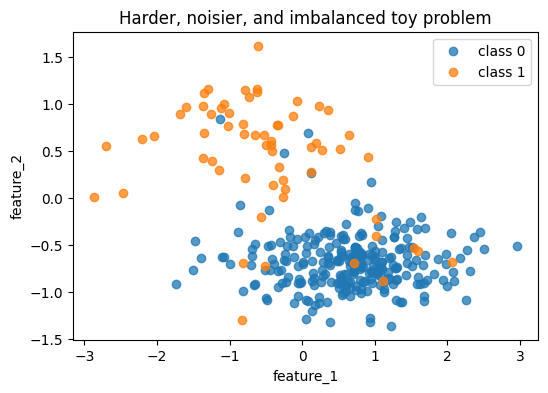

In [5]:
hard_df = make_toy_classification_dataset(
    n_samples=320,
    class_sep=0.7,
    flip_y=0.10,
    weights=(0.82, 0.18),
    random_state=7,
)

ax = plot_classification_dataset(hard_df)
ax.set_title('Harder, noisier, and imbalanced toy problem')
plt.show()


In [6]:
hard_results = evaluate_models_on_dataset(hard_df, scenario='hard_imbalanced', random_state=7)
hard_summary = summarize_classification_results(hard_results)
hard_summary.round(3)


,scenario,model,accuracy,balanced_accuracy,f1,mean_difficulty_proxy
0,hard_imbalanced,decision_tree,0.938,0.842,0.812,0.079
1,hard_imbalanced,knn,0.958,0.895,0.882,0.112
2,hard_imbalanced,logistic_regression,0.948,0.868,0.848,0.152


## Step 3: Compare scenarios side by side

Accuracy often still looks acceptable, but balanced accuracy and F1 reveal a different story when the minority class becomes harder to recover.


In [7]:
comparison = pd.concat([easy_summary, hard_summary], ignore_index=True)
comparison.round(3)


,scenario,model,accuracy,balanced_accuracy,f1,mean_difficulty_proxy
0,easy_balanced,decision_tree,0.990,0.990,0.989,0.010
1,easy_balanced,knn,0.969,0.969,0.969,0.054
2,easy_balanced,logistic_regression,0.979,0.979,0.979,0.116
3,hard_imbalanced,decision_tree,0.938,0.842,0.812,0.079
4,hard_imbalanced,knn,0.958,0.895,0.882,0.112
5,hard_imbalanced,logistic_regression,0.948,0.868,0.848,0.152


## Step 4: Which instances are hard?

Standard metrics collapse everything into a single number. To move toward IRT, we inspect examples directly and ask whether all instances should really contribute equally to evaluation.


In [8]:
hard_instance_summary = summarize_instance_difficulty(hard_results)
hard_instance_summary.head(10).round(3)


,scenario,example_id,feature_1,feature_2,label,mean_correct,mean_predicted_probability,mean_difficulty_proxy,disagreement
76,hard_imbalanced,259,-0.812,-0.696,1,0.000,0.082,0.165,0
64,hard_imbalanced,230,1.012,-0.220,1,0.000,0.058,0.115,0
20,hard_imbalanced,82,1.016,-0.408,1,0.000,0.040,0.079,0
17,hard_imbalanced,72,-0.512,-0.721,1,0.000,0.028,0.056,0
35,hard_imbalanced,134,-0.242,0.096,1,0.333,0.456,0.689,1
75,hard_imbalanced,256,-0.069,1.033,1,0.667,0.678,0.311,1
92,hard_imbalanced,310,-0.857,-0.080,0,1.000,0.273,0.547,0
22,hard_imbalanced,88,-0.459,-0.128,0,1.000,0.242,0.485,0
71,hard_imbalanced,244,1.589,-0.326,0,1.000,0.183,0.365,0
95,hard_imbalanced,315,1.591,-0.838,0,1.000,0.162,0.324,0


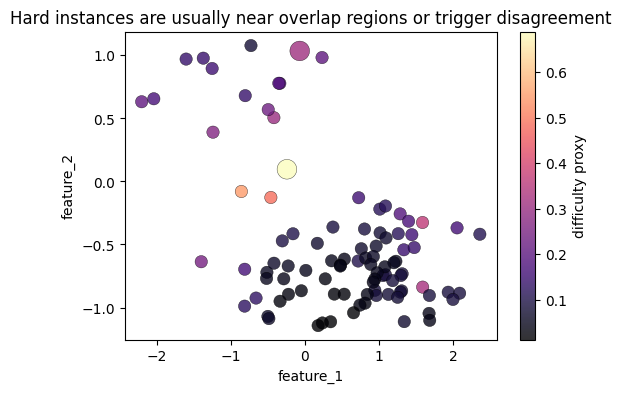

In [ ]:
ax = plot_example_difficulty(hard_instance_summary)
ax.set_title('Hard instances are usually near overlap regions')
plt.show()


## Discussion Prompts

- Which metric changed most from the easy to the hard scenario?
- Which examples seem difficult because of class overlap?
- If two models tie in accuracy, should we trust them equally?
- What is missing when we treat every item as equally informative?


## Bridge to Section 2

This is the key transition: if some items are harder than others, then evaluation should separate **model ability** from **item difficulty**. That is exactly the language introduced by Item Response Theory.
